<a href="https://colab.research.google.com/github/dudwc/PDS2-20252-TM1-Mercado/blob/main/Exemplo_de_Resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

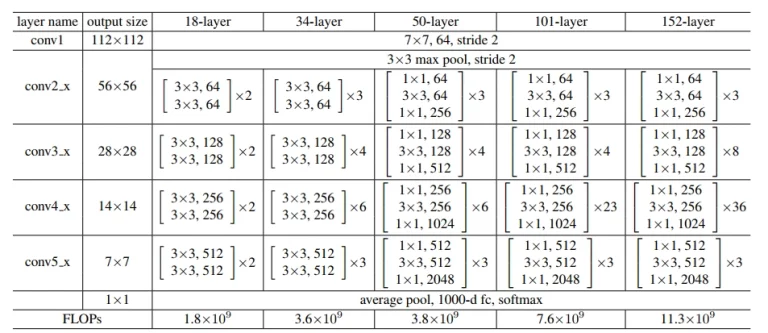

In [13]:
import torch
import torch.nn as nn


class block(nn.Module):
  def __init__(
      self, nos_canais, canais_intermediarios, amostra_identidade=None, stride=1
  ):
    super(block, self).__init__()
    self.expansion = 4
    self.conv1 = nn.Conv2d(
         nos_canais, canais_intermediarios, kernel_size=1, stride=1, padding=0, bias=False
    )
    self.bn1 = nn.BatchNorm2d(canais_intermediarios)
    self.conv2 = nn.Conv2d(
            canais_intermediarios,
            canais_intermediarios,
            kernel_size=3,
            stride=stride,
            padding=0,
            bias=False
    )
    self.bn2 = nn.BatchNorm2d(canais_intermediarios)
    self.conv3 = nn.Conv2d(
            canais_intermediarios,
            canais_intermediarios * self.expansion,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
    )
    self.bn3 = nn.BatchNorm2d(canais_intermediarios * self.expansion)
    self.relu = nn.ReLU()
    self.amostra_identidade = amostra_identidade
    self.stride = stride

    def forward(self, x):
      identidade = x.clone()

      x = self.conv1(x)
      x = self.bn1(x)
      x = self.relu(x)
      x = self.conv2(x)
      x = self.bn2(x)
      x = self.relu(x)
      x = self.conv3(x)
      x = self.bn3(x)

      if self.amostra_identidade is not None:
          identidade = self.amostra_identidade(identidade)

      x += identidade
      x = self.relu(x)
      return x

class ResNet(nn.Module):
  def __init__(self, camadas, canais_imagens, n_classes):
      super(ResNet, self).__init__()
      self.nos_canais = 64
      self.conv1 = nn.Conv2d(canais_imagens, 64, kernel_size=7, stride=2, padding=3, bias=False)
      self.bn1 = nn.BatchNorm2d(64)
      self.relu = nn.ReLU()
      self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

      # arquitetura da ResNet
      self.camada1 = self._make_camada(
      block, camadas[0], canais_intermediarios=64, stride=1
      )
      self.camada2 = self._make_camada(
      block, camadas[1], canais_intermediarios=128, stride=2
      )
      self.camada3 = self._make_camada(
      block, camadas[2], canais_intermediarios=256, stride=2
      )
      self.camada4 = self._make_camada(
      block, camadas[3], canais_intermediarios=512, stride=2
      )

      self.avgpool = nn.AdaptiveAvgPool1d((1,1))
      self.fc = nn.Linear(512 * 4, n_classes)

      def forward(self,x):
          x = self.conv1(x)
          x = self.bn1(x)
          x = self.relu(x)
          x = self.maxpool(x)
          x = self.layer1(x)
          x = self.layer2(x)
          x = self.layer3(x)
          x = self.layer4(x)
          x = self.layer4(x)

      x = self.avgpool(x)
      x = self.reshape(x.shape[0], -1)
      x = self.fc(x)

      return x

      def _make_camada(self, block, n_blocos_residuais, canais_intermediarios, stride):
            amostra_identidade = None
            camadas = []

# precisa-se adaptar a identidade (ignorar conexão) para que ela possa ser adicionada.
# para a camada que tá a frente
            if stride != 1 or self.nos_canais != canais_intermediarios * 4:
                amostra_identidade = nn.Sequencia(
                  nn.Conv2d(
                    self.nos_canais,
                    canais_intermediarios * 4,
                    kernel_size=1
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(canais_intermediarios * 4),

            )

            camadas.append(
              block(self.nos_canais, canais_intermediarios, amostra_identidade, stride)
        )

        self.nos_canais = canais_intermediarios * 4

        for i in range(n_blocos_residuais - 1):
          camadas.append(block(self.in_channels, canais_intermediarios))

        return nn.Sequential(*camadas)

    def Resnet50(canais_imagens=3, n_classes=1000):
      return Resnet(block, [3, 4, 6, 3], canais_imagens, n_classes)

    def Resnet101(canais_imagens=3, n_classes=1000):
      return Resnet(block, [3, 4, 23, 3], canais_imagens, n_classes)

    def Resnet152(canais_imagens=3, n_classes=1000):
      return Resnet(block, [3, 4, 36, 3], canais_imagens, n_classes)

    def test():
      net = ResNet101(canais_imagens=3,n_classes=1000)
      device = "cuda" if torch.cuda.is_available() else "cpu"
      y = net(torch.randn(4, 3, 224, 224)).to(device)
      print(y.size())

  test()

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 122)